## Setup enviroment

In [ ]:
# !pip install -q nilearn

from nilearn import datasets
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np
from nilearn import plotting
from nilearn.connectome import ConnectivityMeasure
from nilearn.image import index_img

Save data

In [ ]:
data_dir = None # change this variable with the path where you want nilearn to download
                # the data, if you leave None, the default will be '~/nilearn_data'

# Loading the functional datasets
data = datasets.fetch_development_fmri(n_subjects=1, data_dir=data_dir)

# you can use the .keys() method to check what's in the dataset
data.keys()

[fetch_development_fmri] Added README.md to /root/nilearn_data

[fetch_development_fmri] Dataset created in /root/nilearn_data/development_fmri

[fetch_development_fmri] Added README.md to /root/nilearn_data/development_fmri

[fetch_development_fmri] Dataset created in /root/nilearn_data/development_fmri/development_fmri

[fetch_development_fmri] Downloading data from https://osf.io/yr3av/download ...

[fetch_development_fmri]  ...done. (5 seconds, 0 min)

[fetch_development_fmri] Dataset found in /root/nilearn_data/development_fmri/development_fmri

[fetch_development_fmri] Downloading data from https://osf.io/download/5c8ff3df4712b400183b7092/ ...

[fetch_development_fmri]  ...done. (4 seconds, 0 min)

[fetch_development_fmri] Downloading data from https://osf.io/download/5c8ff3e04712b400193b5bdf/ ...

[fetch_development_fmri] Downloaded 376832 of 5642698 bytes (6.7%%,   14.1s remaining)

[fetch_development_fmri]  ...done. (6 seconds, 0 min)

dict_keys(['func', 'confounds', 'phenotypic', 'description', 't_r'])

Data path

In [ ]:
fmri_filepath = data.func[0]
print(fmri_filepath)

/root/nilearn_data/development_fmri/development_fmri/sub-pixar123_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz


load fmri_img

In [ ]:
fmri_img = nib.load(fmri_filepath)

atlas dataset

In [ ]:
atlas_dataset = datasets.fetch_atlas_msdl(data_dir=data_dir)
atlas_filepath = atlas_dataset.maps
labels = atlas_dataset.labels

[fetch_atlas_msdl] Dataset created in /root/nilearn_data/msdl_atlas

[fetch_atlas_msdl] Downloading data from https://team.inria.fr/parietal/files/2015/01/MSDL_rois.zip ...

[fetch_atlas_msdl]  ...done. (2 seconds, 0 min)

[fetch_atlas_msdl] Extracting data from 
/root/nilearn_data/msdl_atlas/dedd5c670ed1fd457a722109d3c7f958/MSDL_rois.zip...

[fetch_atlas_msdl] .. done.

NiftiMapsMasker

In [ ]:
from nilearn.input_data import NiftiMapsMasker

atlas_masker = NiftiMapsMasker(maps_img=atlas_filepath, standardize=True)

data_in_atlas = atlas_masker.fit_transform(fmri_filepath, confounds=data.confounds)
data_in_atlas.shape

/tmp/ipykernel_5086/124316530.py:5: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  data_in_atlas = atlas_masker.fit_transform(fmri_filepath, confounds=data.confounds)
/tmp/ipykernel_5086/124316530.py:5: DeprecationWarning: From release 0.14.0, confounds will be standardized using the sample std instead of the population std.
  data_in_atlas = atlas_masker.fit_transform(fmri_filepath, confounds=data.confounds)


(168, 39)

Connectome measure

In [ ]:
from nilearn.connectome import ConnectivityMeasure
correlation_measure = ConnectivityMeasure(kind='correlation')
correlation_matrix = correlation_measure.fit_transform([data_in_atlas])[0]

/tmp/ipykernel_5086/138364204.py:3: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the default strategy will be replaced by the new strategy, the 'zscore' option will be removed. and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  correlation_matrix = correlation_measure.fit_transform([data_in_atlas])[0]



# Exercises

## 1. Of the importance of confounds

* Generate a correlation matrix with the same data, but this time without using the confounds when masking.

How does that impact the correlation matrix ?
Why do you think it affects the matrix this way ?

* Plot the obtained connectome in 3D using `nilearn.plotting.view_connectome` (check [the doc](https://nilearn.github.io/modules/generated/nilearn.plotting.view_connectome.html) to know how to use it).

/tmp/ipykernel_5086/2430270386.py:3: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  data_nocon = atlas_masker_nocon.fit_transform(fmri_filepath)
/tmp/ipykernel_5086/2430270386.py:6: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the default strategy will be replaced by the new strategy, the 'zscore' option will be removed. and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  matrix_nocon = correlation_measure.fit_transform([

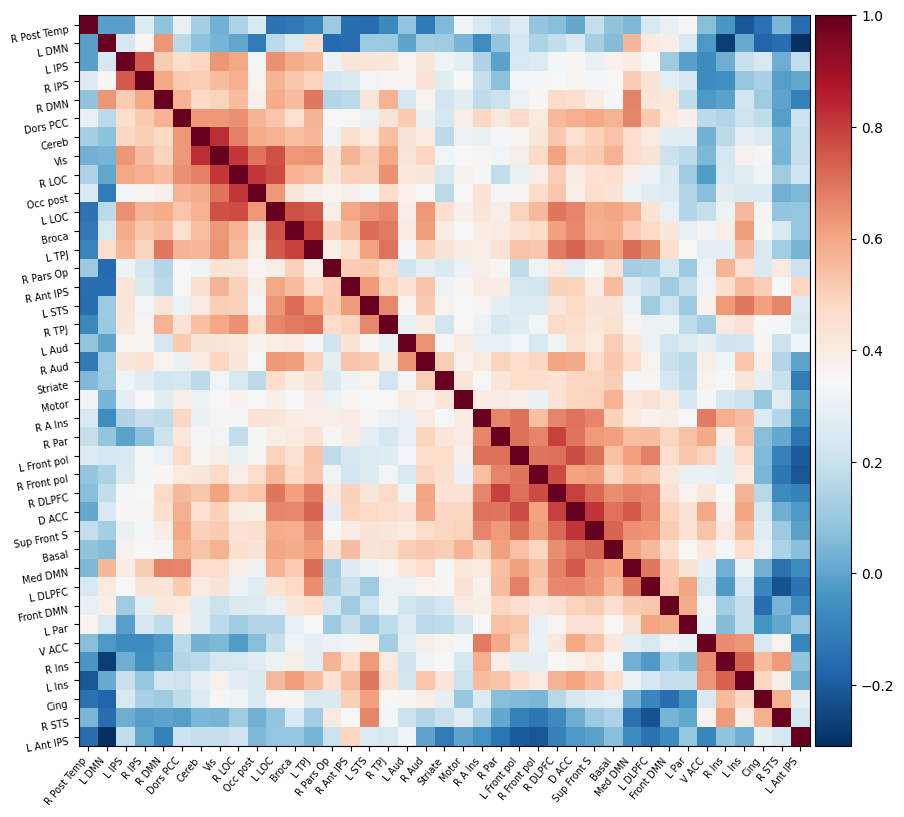

In [ ]:
# as example
atlas_masker_nocon = NiftiMapsMasker(maps_img=atlas_filepath, standardize=True)
data_nocon = atlas_masker_nocon.fit_transform(fmri_filepath)

correlation_measure = ConnectivityMeasure(kind='correlation')
matrix_nocon = correlation_measure.fit_transform([data_nocon])[0]

# take a look at matrix_nocon
plotting.plot_matrix(matrix_nocon, figure=(10, 8), labels=labels, reorder=True)



# plot = plotting.plot_matrix(matrix_nocon, colorbar=True, title="Functional connectivity matrix without confounds")
# plot

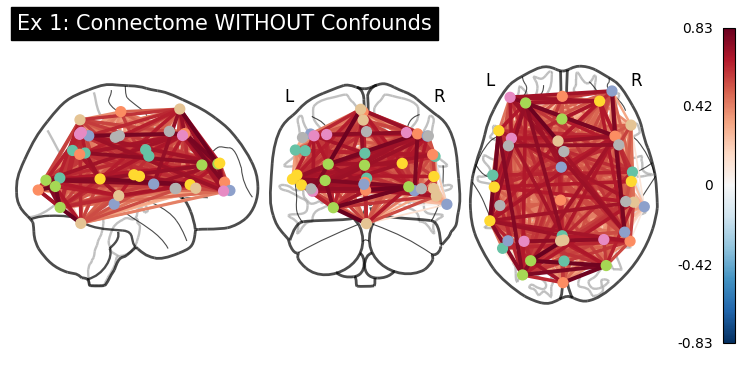

In [ ]:
plotting.plot_connectome(matrix_nocon, atlas_dataset.region_coords, title="Ex 1: Connectome WITHOUT Confounds")

## 2. Visualizing the atlas and a specific time point

* Use `view_img` to visualize the 5th ROI of the atlas. (Hint: use the atlas masker to inverse transform an array with 1 at the index 4 and 0 every where else.)

* Use `plotting.plot_prob_atlas` to show all the ROIs with filled contours. (Hint: check the nilearn documentation to see how to use `plotting.plot_prob_atlas`).
* Earlier we used `view_img` to plot the mean volume of our `fmri_img` data because `view_img` doesn't accept 4D images but only 3D ones. Find a way to generate a 3D Nifti image with the 84th time point in `fmri_img` and plot it with `view_img`.

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:820: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



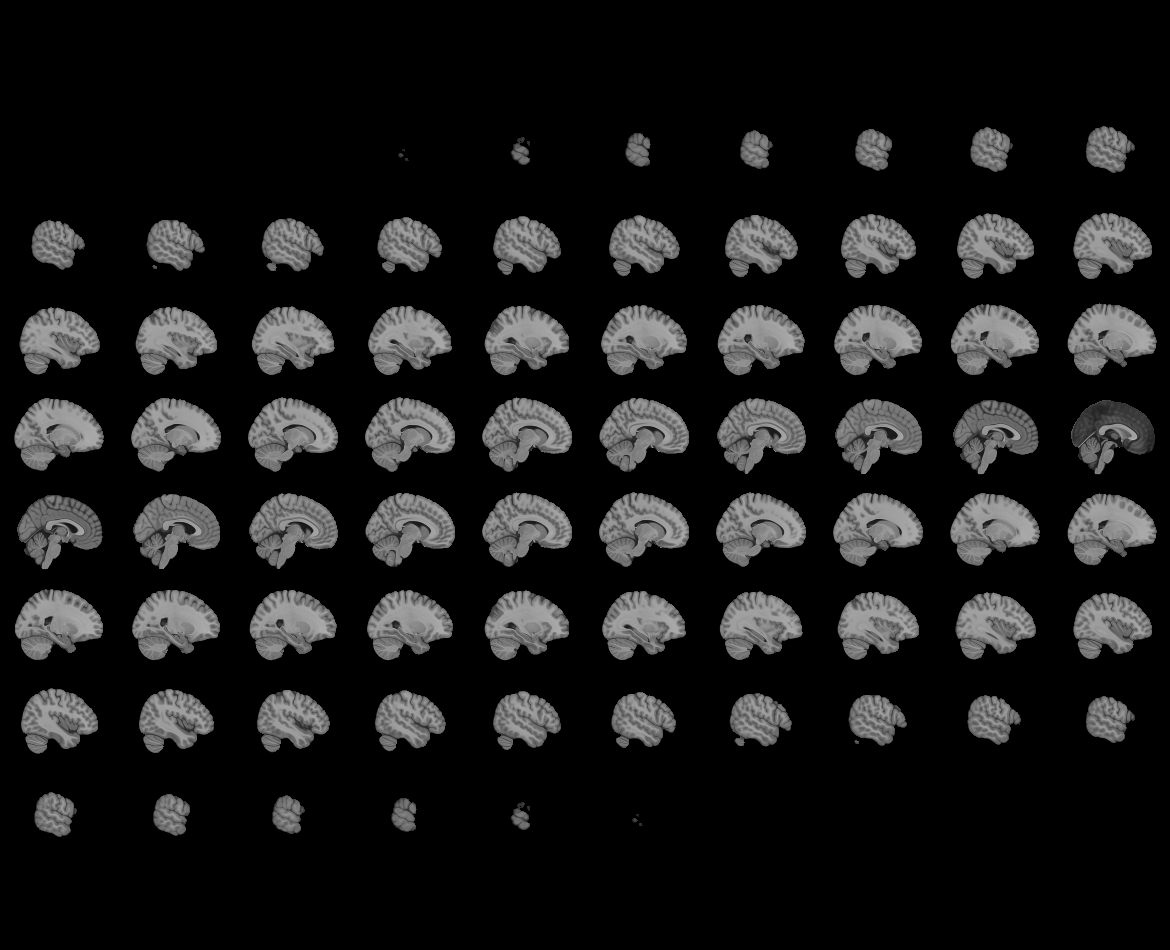
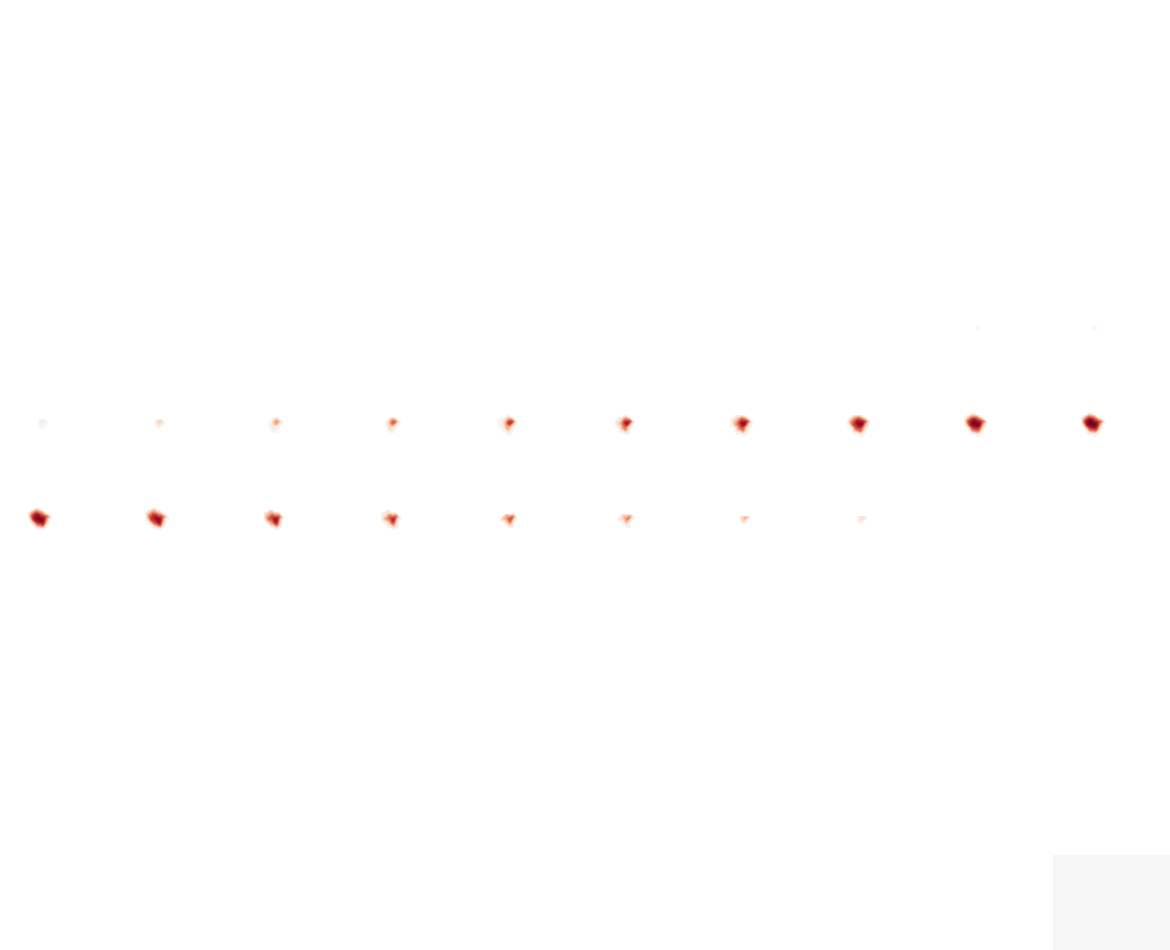

In [ ]:
from nilearn.plotting import view_img

roi_array = np.zeros(len(atlas_dataset.labels))
roi_array[4] = 1
roi_5_img = atlas_masker.inverse_transform(roi_array)

view_img(roi_5_img)

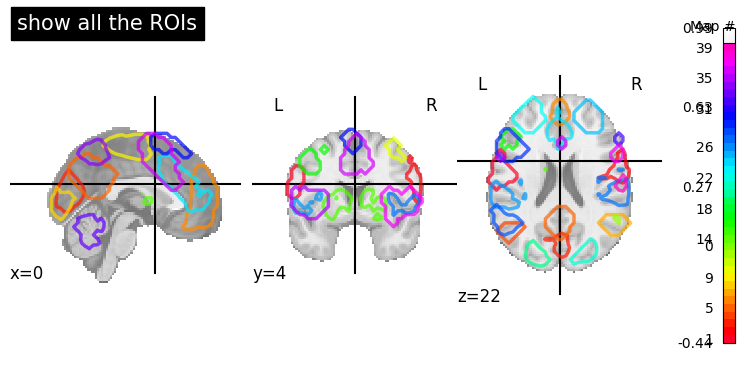

In [ ]:
plotting.plot_prob_atlas(atlas_filepath, title="show all the ROIs")

/tmp/ipykernel_5086/2917277322.py:4: UserWarning: Threshold given was 1e-06, but the data has no values below -121.83067321777344. 
  view_Xth = plotting.view_img(img_Xth, title=f"Volume {Xth_Volume}")
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:820: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/tmp/ipykernel_5086/2917277322.py:4: UserWarning: It seems you have created more than 10 nilearn views. As each view uses dozens of megabytes of RAM, you might want to delete some of them.
  view_Xth = plotting.view_img(img_Xth, title=f"Volume {Xth_Volume}")



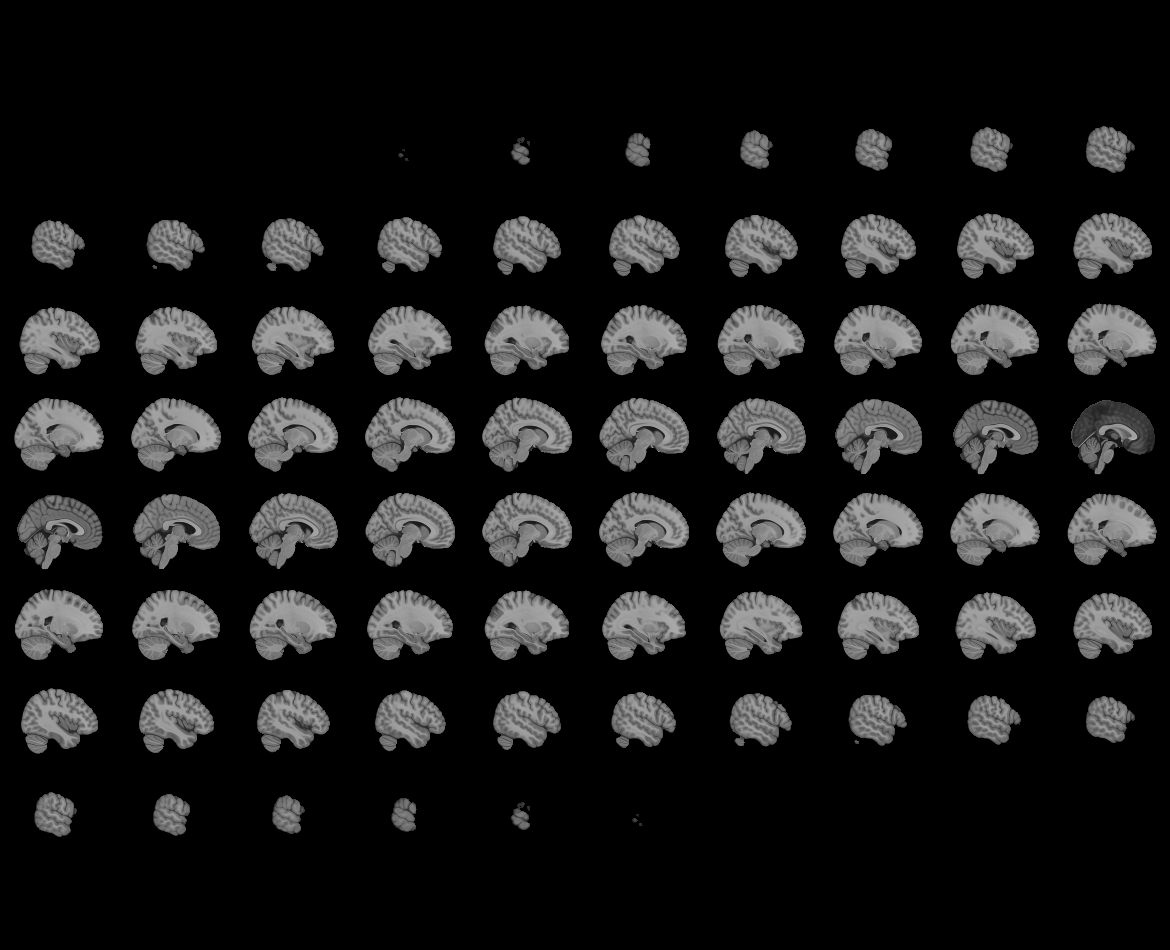
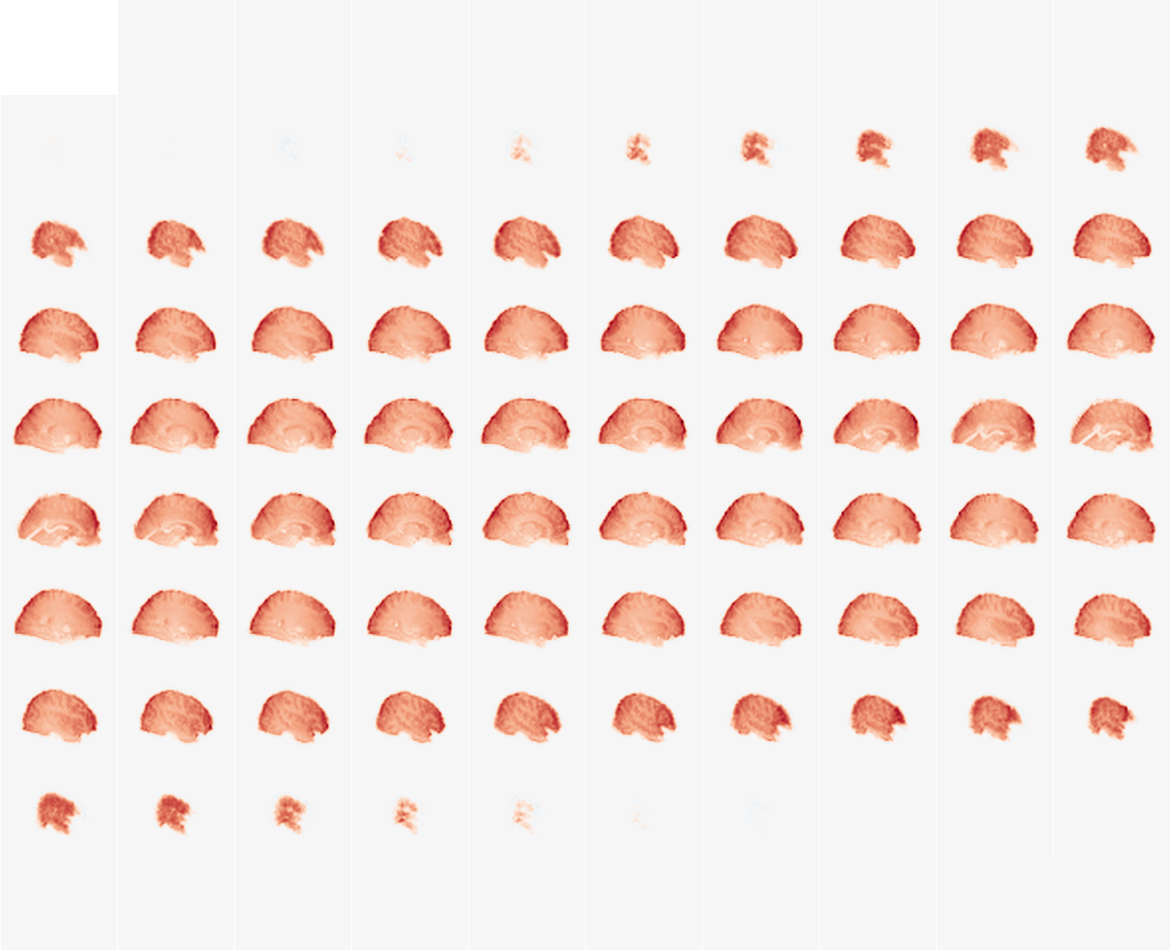

In [ ]:
Xth_Volume = 84 # @param {type:"integer"}
img_Xth = index_img(fmri_img, Xth_Volume-1)

view_Xth = plotting.view_img(img_Xth, title=f"Volume {Xth_Volume}")
view_Xth

## 3. Seed-based connectivity

*Using the information provided in [this nilearn tutorial](https://nilearn.github.io/stable/auto_examples/03_connectivity/plot_seed_to_voxel_correlation.html), plot the seed-to-voxel correlation map of our fmri_img for the seed of coordinates (-16, -74, 7) and with a sphere mask of radius of size 10.

In [ ]:
from nilearn.maskers import NiftiSpheresMasker
from nilearn.input_data import NiftiMasker

/tmp/ipykernel_5086/1625397432.py:3: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  seed_time_series = seed_nsmasker.fit_transform(fmri_filepath, confounds=data.confounds)
/tmp/ipykernel_5086/1625397432.py:3: DeprecationWarning: From release 0.14.0, confounds will be standardized using the sample std instead of the population std.
  seed_time_series = seed_nsmasker.fit_transform(fmri_filepath, confounds=data.confounds)
/tmp/ipykernel_5086/1625397432.py:6: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be remov

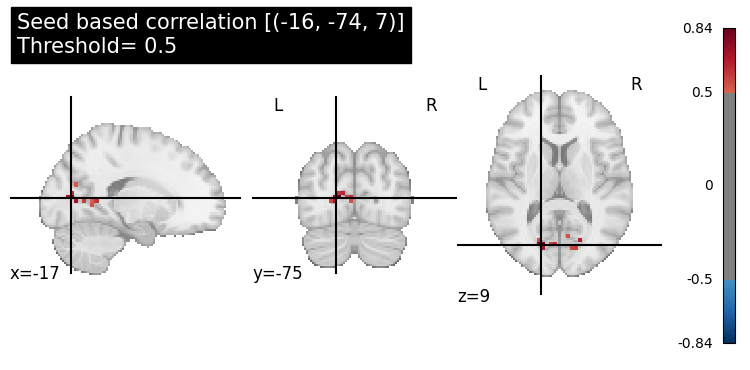

In [ ]:
seed = [(-16, -74, 7)]
seed_nsmasker = NiftiSpheresMasker(seed, radius=4.5, standardize=True)
seed_time_series = seed_nsmasker.fit_transform(fmri_filepath, confounds=data.confounds)

brain_masker = NiftiMasker(standardize=True)
brain_time_series = brain_masker.fit_transform(fmri_filepath, confounds=data.confounds)

seed_to_voxel_correlations = (np.dot(brain_time_series.T, seed_time_series) / seed_time_series.shape[0])
seed_to_voxel_correlations_img = brain_masker.inverse_transform(seed_to_voxel_correlations.T)

threshold = 0.5
plotting.plot_stat_map(seed_to_voxel_correlations_img, threshold=threshold, title=f"Seed based correlation {seed}\nThreshold= {threshold}")
plt.show()